In [1]:
# Native libraries
import os
import math
# Essential Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Preprocessing
from sklearn.preprocessing import MinMaxScaler
# Algorithms
#from minisom import MiniSom
from tslearn.barycenters import dtw_barycenter_averaging
from tslearn.clustering import TimeSeriesKMeans
from sklearn.cluster import KMeans
import cartopy.crs as ccrs
import cartopy
import susi
from sklearn.model_selection import GridSearchCV
import xarray as xr
import matplotlib._color_data as mcd
import matplotlib.gridspec as gridspec

from sklearn.decomposition import PCA

/home/queenle/.conda/envs/myenv/lib/python3.6/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
/home/queenle/.conda/envs/myenv/lib/python3.6/site-packages/tslearn/clustering/kmeans.py:17: UserWarning: Scikit-learn <0.24 will be deprecated in a future release of tslearn
  "Scikit-learn <0.24 will be deprecated in a "


In [2]:
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)
'''
# load flow data into dataframe
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/full_records.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)
'''
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)

# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)

metadata_df = pd.read_csv('../data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

# define alpha and numeric season order
seasons_a = {3:'autumn',6:'winter',9:'spring',12:'summer'}
seasons_n = [3,6,9,12]

# load flow data into dataframe
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/all_sites_all_seasons.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)

colors = ['r','b',"#000000", "#FFFF00", "#1CE6FF", "#FF34FF", "#FF4A46", "#008941", "#006FA6", "#A30059",
"#FFDBE5", "#7A4900", "#0000A6", "#63FFAC", "#B79762", "#004D43", "#8FB0FF", "#997D87",
"#5A0007", "#809693", "#FEFFE6", "#1B4400", "#4FC601", "#3B5DFF", "#4A3B53", "#FF2F80",
"#61615A", "#BA0900", "#6B7900", "#00C2A0", "#FFAA92", "#FF90C9", "#B903AA", "#D16100",
"#DDEFFF", "#000035", "#7B4F4B", "#A1C299", "#300018", "#0AA6D8", "#013349", "#00846F",
"#372101", "#FFB500", "#C2FFED", "#A079BF", "#CC0744", "#C0B9B2", "#C2FF99", "#001E09",
"#00489C", "#6F0062", "#0CBD66", "#EEC3FF", "#456D75", "#B77B68", "#7A87A1", "#788D66",
"#885578", "#FAD09F", "#FF8A9A", "#D157A0", "#BEC459", "#456648", "#0086ED", "#886F4C",
"#34362D", "#B4A8BD", "#00A6AA", "#452C2C", "#636375", "#A3C8C9", "#FF913F", "#938A81",
"#575329", "#00FECF", "#B05B6F", "#8CD0FF", "#3B9700", "#04F757", "#C8A1A1", "#1E6E00",
"#7900D7", "#A77500", "#6367A9", "#A05837", "#6B002C", "#772600", "#D790FF", "#9B9700",
"#549E79", "#FFF69F", "#201625", "#72418F", "#BC23FF", "#99ADC0", "#3A2465", "#922329",
"#5B4534", "#FDE8DC", "#404E55", "#0089A3", "#CB7E98", "#A4E804", "#324E72", "#6A3A4C"]

colors.pop(34)
colors.pop(35)
colors.pop(20)
colors[15], colors[40] = colors[40], colors[15]


FileNotFoundError: [Errno 2] File ../data/metadata/40_50yr_sites.csv does not exist: '../data/metadata/40_50yr_sites.csv'

In [3]:
def plot_cluster_series(som_x, som_y, axs):
    '''
    plt.rc('font', size=20)          # controls default text sizes
    plt.rc('axes', titlesize=20)     # fontsize of the axes title
    plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
    plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=20)    # fontsize of the tick labels
    plt.rc('legend', fontsize=20)    # legend fontsize
    plt.rc('figure', titlesize=20)  # fontsize of the figure title
    '''
    for x in range(som_x):
        for y in range(som_y):
            cluster = (x,y)
            cluster_number = x*som_y+y+1
            
            series_indices = som.get_datapoints_from_node(cluster)
            
            ts_list = []
            for i in series_indices:
                ts = X[i]
                ts_list.append(ts)
                axs[cluster_number-1].plot(ts,c="gray",alpha=0.5) 
            
            if ts_list == []:
                continue
            axs[cluster_number-1].plot(dtw_barycenter_averaging(ts_list),c=colors[cluster_number-1],linewidth=2,label=str(x) + " " + str(y))
            axs[cluster_number-1].legend(loc='upper left')
            axs[cluster_number-1].set_ylim(-2,4)
            
            if x != som_x-1:
                axs[cluster_number-1].get_xaxis().set_ticks([])
                
            if y != 0:
                axs[cluster_number-1].get_yaxis().set_ticks([])
                


In [4]:
def plot_cluster_map(df,som_x,som_y,ax):
    sites = df.index.values

    lons = []
    lats = []
    clusters = []

    for x in range(som_x):
        for y in range(som_y):
            cluster = (x,y)
            cluster_number = x*som_y+y+1

            series_indices = som.get_datapoints_from_node(cluster)

            for i in series_indices:
                site = int(sites[i])

                lons.append(metadata_df.loc[site]['centroid_lon'])
                lats.append(metadata_df.loc[site]['centroid_lat'])
                clusters.append(cluster_number)

    ax.scatter(lons,lats,marker='s',s=70,c=[colors[val-1] for val in clusters])
    ax.coastlines(resolution='50m', color='black', linewidth=1)
    ax.set_xlim([164,180])

In [6]:
for season in [6,12]:
    for iteration in [500,10000,50000]:
        for learning_rate in [1,0.5,0.05]:
            for size in [2,3,4]:
                for count in range(5):
                    #### define data and constants ####
                    som_x = som_y = size

                    df = flow_df[flow_df.index.month.isin([season])] # select season
                    #df = flow_df.resample('A').mean()
                    df = df.fillna(df.mean())
                    df=((df-df.mean())/df.std()).T # normalize
                    X = df.values

                    #### define figure

                    fig = plt.figure()
                    fig.set_figheight(12)
                    fig.set_figwidth(22)

                    umat_ax = plt.subplot2grid(shape=(2, 2), loc=(0, 1))
                    map_ax = plt.subplot2grid(shape=(2, 2), loc=(1, 1), projection=ccrs.PlateCarree())

                    ts_axs = []
                    for i in range(som_x):
                        for j in range(som_x):
                            ax = plt.subplot2grid(shape=(som_x, som_x*2), loc=(i,j))
                            ts_axs.append(ax)

                    #### runs SOMs

                    som = susi.SOMClustering(som_x,som_y,n_iter_unsupervised=iteration,learning_rate_start=learning_rate)
                    som.fit(X)

                    #### plot U-matrix ####

                    umat = som.get_u_matrix()
                    p = umat_ax.imshow(np.squeeze(umat),cmap='Greys')
                    umat_ax.scatter([[2*i]*som_x for i in range(som_x)],[2*i for i in range(som_x)]*som_x,marker='*',c='r')

                    umat_ax.get_xaxis().set_ticks([])
                    umat_ax.get_yaxis().set_ticks([])

                    #### plot time series by cluster ####

                    plot_cluster_series(som_x,som_y,ts_axs)

                    #### plot cluster map ####

                    plot_cluster_map(df,som_x,som_y,map_ax)

                    #### save figure and clear ####

                    plt.subplots_adjust(wspace=0, hspace=0)
                    plt.suptitle(seasons_a[season] + "_" + str(som_x) + "_" + str(iteration) + "_" + str(learning_rate) + "_" + str(count))

                    plt.savefig('/nesi/project/niwa00015/queenle/plots/SOMs/' + seasons_a[season] + "/" + seasons_a[season] + "_" + str(som_x) + "_" + str(iteration) + "_" + str(learning_rate) + "_" + str(count) + ".png",dpi=300)
                                     
                    plt.close()
                    
                    print("finished " + seasons_a[season] + "_" + str(som_x) + "_" + str(iteration) + "_" + str(learning_rate) + "_" + str(count))


finished winter_2_500_1_0
finished winter_2_500_1_1
finished winter_2_500_1_2
finished winter_2_500_1_3
finished winter_2_500_1_4
finished winter_3_500_1_0
finished winter_3_500_1_1
finished winter_3_500_1_2
finished winter_3_500_1_3
finished winter_3_500_1_4
finished winter_4_500_1_0
finished winter_4_500_1_1
finished winter_4_500_1_2
finished winter_4_500_1_3
finished winter_4_500_1_4
finished winter_2_500_0.5_0
finished winter_2_500_0.5_1
finished winter_2_500_0.5_2
finished winter_2_500_0.5_3
finished winter_2_500_0.5_4
finished winter_3_500_0.5_0
finished winter_3_500_0.5_1
finished winter_3_500_0.5_2
finished winter_3_500_0.5_3
finished winter_3_500_0.5_4
finished winter_4_500_0.5_0
finished winter_4_500_0.5_1
finished winter_4_500_0.5_2
finished winter_4_500_0.5_3
finished winter_4_500_0.5_4
finished winter_2_500_0.05_0
finished winter_2_500_0.05_1
finished winter_2_500_0.05_2
finished winter_2_500_0.05_3
finished winter_2_500_0.05_4
finished winter_3_500_0.05_0
finished winter_

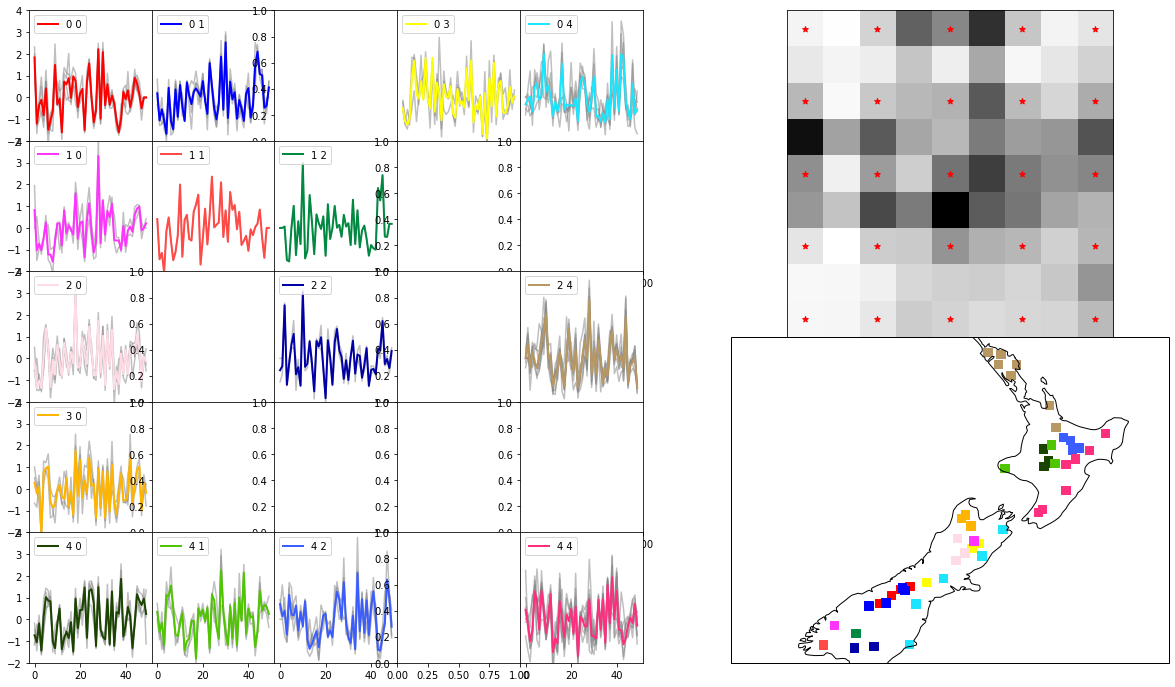